# Predição de vendas

# Importações

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.linear_model  import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Carregamento e exploração dos dados

In [ ]:
df = pd.read_csv("dados_analise_processo_seletivo_aidron.csv")

# converte o period para datetime
df["period"] = pd.to_datetime(df["period"])

# ordena as datas
df = df.sort_values('period').reset_index(drop=True)
print(f"Total de registros: {len(df)}")



Total de registros: 42
      period  month_sin     month_cos  t
0 2022-01-31   0.500000  8.660254e-01  0
1 2022-02-28   0.866025  5.000000e-01  1
2 2022-03-31   1.000000  6.123234e-17  2


In [8]:
# Verificar valores anômalos na coluna 'margem'
anomalias = df[df['margem'] < 0][['period','margem']]
print(f"Registros com margem negativa ({len(anomalias)} ocorrências):")
print(anomalias.to_string(index=False)) # quais linhas possuem margem negativa

Registros com margem negativa (6 ocorrências):
    period    margem
2022-04-30 -1.613145
2023-04-30 -0.148858
2023-05-31 -0.165189
2023-08-31 -0.518651
2024-03-31 -0.099491
2024-07-31 -1.540031


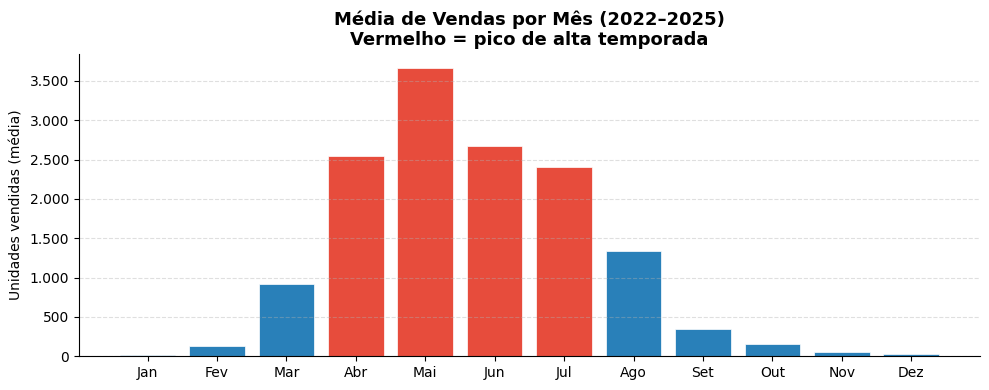


O produto apresenta forte sazonalidade:
  Pico:  Abr–Jul (média ~2820 unidades)
  Vale:  Nov–Jan (média ~32 unidades)


In [9]:
# Sazonalidade: vendas médias por mês
meses_labels = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
saz = df.groupby(df['period'].dt.month)['target'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
cores = ['#E74C3C' if m in [4,5,6,7] else '#2980B9' for m in saz.index]
ax.bar(meses_labels, saz.values, color=cores, edgecolor='white', linewidth=0.5)
ax.set_title('Média de Vendas por Mês (2022–2025)\nVermelho = pico de alta temporada', fontsize=13, fontweight='bold')
ax.set_ylabel('Unidades vendidas (média)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nO produto apresenta forte sazonalidade:")
print(f"  Pico:  Abr–Jul (média ~{saz[[4,5,6,7]].mean():.0f} unidades)")
print(f"  Vale:  Nov–Jan (média ~{saz[[11,12,1]].mean():.0f} unidades)")

# Features

In [10]:
# features de tempo
df['month'] = df['period'].dt.month
df['year'] = df['period'].dt.year

# sazonalidade cíclica: faz com que janeiro e dezembro fiquem próximos no espaço de features 
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# tendência linear: cada linha é um ponto no tempo (0, 1, 2, ...)
df['t'] = np.arange(len(df))

print(df[['period','month_sin','month_cos','t']].head(3))

      period  month_sin     month_cos  t
0 2022-01-31   0.500000  8.660254e-01  0
1 2022-02-28   0.866025  5.000000e-01  1
2 2022-03-31   1.000000  6.123234e-17  2


# Treino e Teste

In [11]:

features = [
    'price',
    'margem',
    'month_sin',
    'month_cos',
    't'
]

X = df[features] #entrada 
y = df["target"] #saída

# Os últimos 5 meses (Fev–Jun/2025) são usados como teste
n_test = 5

X_train = X.iloc[:-n_test]   # Jan/2022 a Jan/2025 (37 amostras)
X_test  = X.iloc[-n_test:]   # Fev/2025 a Jun/2025 (5 amostras)
y_train = y.iloc[:-n_test]
y_test  = y.iloc[-n_test:]


print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 37 amostras | Teste: 5 amostras


# Normalização

In [12]:
# criar scaler
scaler = StandardScaler()


# fit_transform no treino: aprende a média e desvio do treino
X_train_sc = scaler.fit_transform(X_train)

# transform no teste: aplica os parâmetros aprendidos no treino
X_test_sc = scaler.transform(X_test)

# Verificar resultado
print("Média antes:",  X_train['price'].mean().round(1))
print("Média depois:", X_train_sc[:, 0].mean().round(4))  # ≈ 0.0
print("Desvio depois:", X_train_sc[:, 0].std().round(4)) # ≈ 1.0


Média antes: 91.1
Média depois: 0.0
Desvio depois: 1.0


# Seleção do melhor alpha para o Ridge

In [13]:
alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500, 1000] # lista de alphas para teste

# TimeSeriesSplit: mantém a ordem temporal nas folds
tscv = TimeSeriesSplit(n_splits=4)

# GridSearchCV testa cada alpha com cross-validation temporal
grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': alphas},
    cv=tscv,
    scoring='neg_mean_absolute_error',
    refit=True
)
grid.fit(X_train_sc, y_train)


best_alpha = grid.best_params_['alpha']
print(f"Melhor alpha: {best_alpha}")
print(f"MAE médio CV: {-grid.best_score_:.1f}")


Melhor alpha: 5
MAE médio CV: 628.7


# Treinamento final e métricas de avaliação

In [17]:
# Treinar com o melhor alpha
model = Ridge(alpha=best_alpha)
model.fit(X_train_sc, y_train)

# Predizer no conjunto de teste
pred = model.predict(X_test_sc)

# Garantir que não haja vendas negativas
pred = np.maximum(pred, 0)

# Calcular métricas de avaliação
mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print("Desempenho no teste: ")
print("="*45)
print(f"MAE (Erro Médio Absoluto):  {mae:.1f} unidades")   # erro médio absoluto
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.1f} unidades")  # raiz do erro quadrático
print(f"R² (Variância explicada):   {r2:.3f}")   # proporção da variância explicada
print("="*45)

# Ver o peso de cada feature
coefs = pd.Series(model.coef_, index=features)
print("Coeficientes:")
print(coefs.round(1).sort_values(ascending=False))

Desempenho no teste: 
MAE (Erro Médio Absoluto):  940.1 unidades
RMSE (Raiz do Erro Quadrático): 1164.8 unidades
R² (Variância explicada):   0.121
Coeficientes:
month_sin     196.4
price          54.8
t             -71.9
margem       -234.6
month_cos   -1000.6
dtype: float64


# Métrica Principal: MAE (Erro Médio Absoluto)

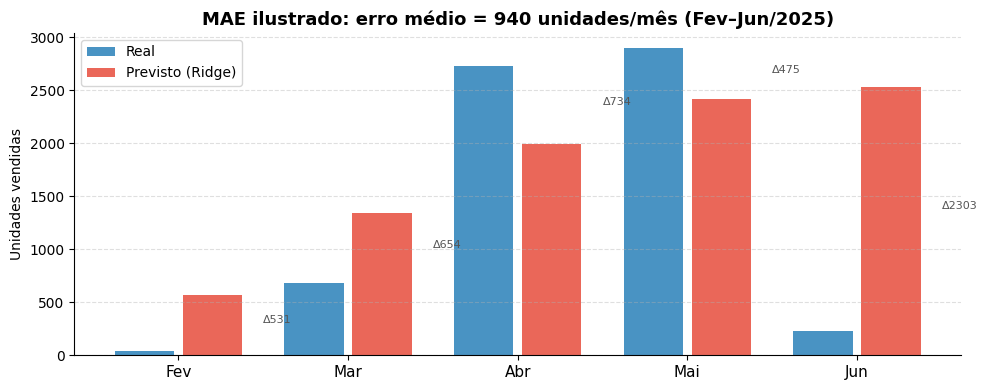

In [18]:
# Visualização: MAE ilustrado
meses_labels_teste = ['Fev','Mar','Abr','Mai','Jun']
x_vals = np.arange(5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_vals - 0.2, y_test.values, width=0.35, color='#2980B9', label='Real', alpha=0.85)
ax.bar(x_vals + 0.2, pred, width=0.35, color='#E74C3C', label='Previsto (Ridge)', alpha=0.85)
for i in x_vals:
    erro = abs(y_test.values[i] - pred[i])
    ax.text(i + 0.5, (y_test.values[i] + pred[i])/2, f'Δ{int(erro)}', fontsize=8, color='#555555')
ax.set_xticks(x_vals)
ax.set_xticklabels(meses_labels_teste, fontsize=11)
ax.set_title(f'MAE ilustrado: erro médio = {mae:.0f} unidades/mês (Fev–Jun/2025)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('Unidades vendidas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Visualização do real x predito

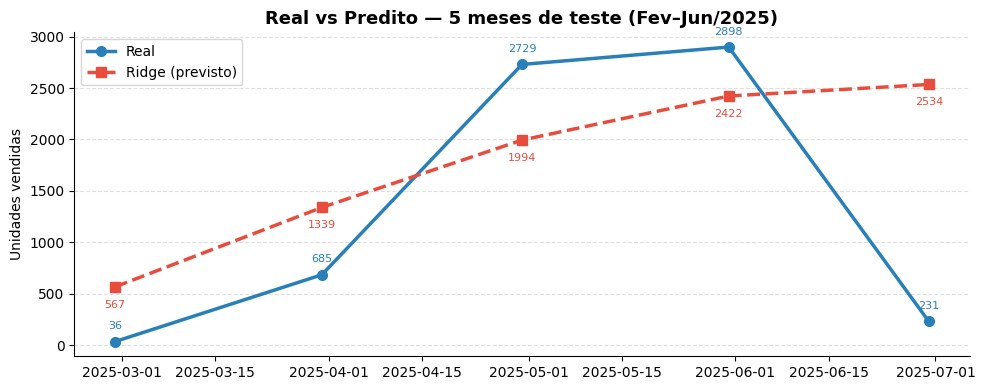

In [20]:
datas_teste = df['period'].iloc[-n_test:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(datas_teste, y_test.values, 'o-', color='#2980B9', lw=2.5, label='Real', markersize=7)
ax.plot(datas_teste, pred, 's--', color='#E74C3C', lw=2.5, label='Ridge (previsto)', markersize=7)
for d, r, p in zip(datas_teste, y_test.values, pred):
    ax.annotate(f'{int(r)}', (d, r), textcoords='offset points', xytext=(0, 9), ha='center', fontsize=8, color='#2980B9')
    ax.annotate(f'{int(p)}', (d, p), textcoords='offset points', xytext=(0, -15), ha='center', fontsize=8, color='#E74C3C')
ax.set_title('Real vs Predito — 5 meses de teste (Fev–Jun/2025)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('Unidades vendidas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Avaliação da coluna prediction do CSV

In [24]:
# Aqui é para avaliar a previsão que já estava no csv, sem usar o modelo treinado
pred_csv = df.iloc[-n_test:][['period','target','prediction']].copy().dropna().reset_index(drop=True)
pred_csv['erro_abs'] = (pred_csv['target'] - pred_csv['prediction']).abs()
pred_csv['erro_pct'] = (pred_csv['erro_abs'] / pred_csv['target'] * 100).round(1)

mae_csv  = pred_csv['erro_abs'].mean()
rmse_csv = np.sqrt((pred_csv['erro_abs']**2).mean())
r2_csv   = 1 - ((pred_csv['target'] - pred_csv['prediction'])**2).sum() / \
               ((pred_csv['target'] - pred_csv['target'].mean())**2).sum()

print("Detalhamento por mês:")
print(pred_csv[['period','target','prediction','erro_abs','erro_pct']].to_string(index=False))
print()
print("="*50)
print("  MÉTRICAS DA PREDICTION DO CSV")
print("="*50)
print(f"  MAE:   {mae_csv.round(1)} unidades")
print(f"  RMSE:  {rmse_csv.round(1)} unidades")
print(f"  R²:    {r2_csv.round(1)}")
print("="*50)

Detalhamento por mês:
    period  target  prediction  erro_abs  erro_pct
2025-02-28    36.0   1690.9358 1654.9358    4597.0
2025-03-31   685.0   1687.8474 1002.8474     146.4
2025-04-30  2729.0   1786.0929  942.9071      34.6
2025-05-31  2898.0   1873.1072 1024.8928      35.4
2025-06-30   231.0   2092.6902 1861.6902     805.9

  MÉTRICAS DA PREDICTION DO CSV
  MAE:   1297.5 unidades
  RMSE:  1352.8 unidades
  R²:    -0.2


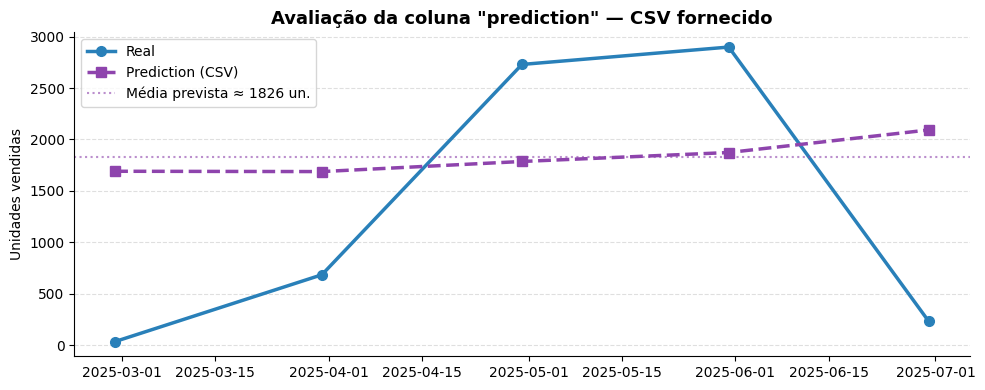

In [26]:
# Gráfico de avaliação da prediction do CSV
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pred_csv['period'], pred_csv['target'], 'o-', color='#2980B9', lw=2.5, label='Real', markersize=7)
ax.plot(pred_csv['period'], pred_csv['prediction'], 's--', color='#8E44AD', lw=2.5, label='Prediction (CSV)', markersize=7)
ax.axhline(pred_csv['prediction'].mean(), color='#8E44AD', linestyle=':', alpha=0.6,
           label=f'Média prevista ≈ {pred_csv["prediction"].mean():.0f} un.')
ax.set_title('Avaliação da coluna "prediction" — CSV fornecido', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('Unidades vendidas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print()


# Previsão para os próximos 5 meses

In [28]:
ultimo_t = len(df)  # Continua a sequência de tendência após o último dado
meses_futuros = [7, 8, 9, 10, 11]  # Jul a Nov/2025

# Médias históricas de price e margem por mês (base para estimativa das features futuras)
medias = df.groupby('month')[['price','margem']].mean()
print("Médias históricas usadas como input futuro:")
print(medias.loc[meses_futuros].round(2))

futuro = pd.DataFrame({
    'price':     [medias.loc[m,'price'] for m in meses_futuros],
    'margem':    [medias.loc[m,'margem'] for m in meses_futuros],
    'month_sin': [np.sin(2*np.pi*m/12) for m in meses_futuros],
    'month_cos': [np.cos(2*np.pi*m/12) for m in meses_futuros],
    't':         [ultimo_t + i for i in range(5)]
})

futuro_sc = scaler.transform(futuro)
preds_futuros = np.maximum(model.predict(futuro_sc), 0)

nomes = ['Jul/2025','Ago/2025','Set/2025','Out/2025','Nov/2025']
print("\nPrevisão de vendas — próximos 5 meses:")
print("=" * 35)
for mes, val in zip(nomes, preds_futuros):
    barra = '█' * max(1, int(val / 100))
    print(f"  {mes}: {val:>6.0f} un.  {barra}")
print("=" * 35)

Médias históricas usadas como input futuro:
       price  margem
month               
7      91.42   -0.09
8      89.25    0.05
9      90.00    0.61
10     88.85    0.57
11     88.25    0.61

Previsão de vendas — próximos 5 meses:
  Jul/2025:   2386 un.  ███████████████████████
  Ago/2025:   1684 un.  ████████████████
  Set/2025:    700 un.  ███████
  Out/2025:     39 un.  █
  Nov/2025:      0 un.  █


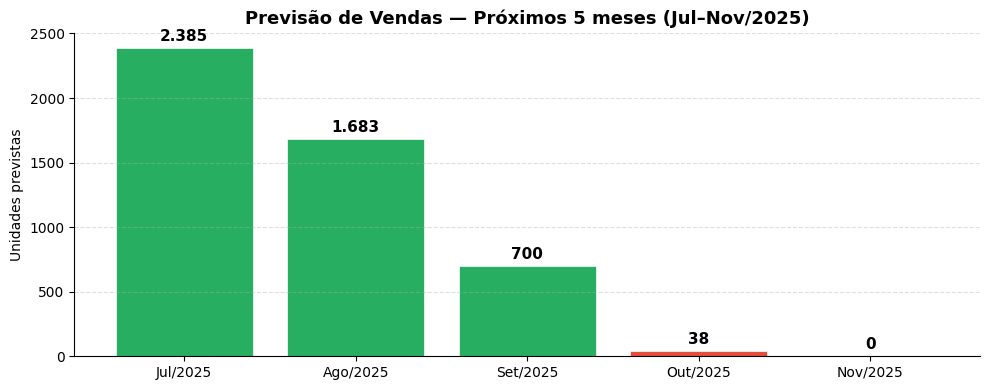

In [31]:
# Gráfico da previsão futura
fig, ax = plt.subplots(figsize=(10, 4))
cores_fut = ['#27AE60' if v > 500 else '#F39C12' if v > 100 else '#E74C3C' for v in preds_futuros]
bars = ax.bar(nomes, preds_futuros, color=cores_fut, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, preds_futuros):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{int(val):,}'.replace(',','.'), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Previsão de Vendas — Próximos 5 meses (Jul–Nov/2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Unidades previstas')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
